In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [16]:
ds_legacy = xr.open_zarr("/Users/elynnw/Downloads/2026-04-16-trial-run/fme_verify_data/legacy_rundir/processed.zarr")
ds = xr.open_dataset("/Users/elynnw/Downloads/2026-04-16-trial-run/fme_verify_data/fme_rundir/SMS_P512.ne30pg2_r05_IcoswISC30E3r5.WCYCL1850.pm-cpu_gnu.allactive-fme_output.20260415_184927_xh6nt1.eam.h0.0001-01-06-00000.nc")

In [20]:
ds_legacy.time

<xarray.DataArray 'time' (time: 1)> Size: 8B
array([cftime.DatetimeNoLeap(1, 1, 6, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 8B 0001-01-06 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds

In [21]:
ds.time

<xarray.DataArray 'time' (time: 1)> Size: 8B
array([cftime.DatetimeNoLeap(1, 1, 6, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 8B 0001-01-06 00:00:00
Attributes:
    long_name:  time
    bounds:     time_bnds

In [17]:
diff = {}
for var in ds.data_vars:
    if var in ds_legacy.data_vars:
        try:
            diff[var] = ds[var] - ds_legacy[var]
        except:
            pass

In [18]:
diff.keys()

dict_keys(['hyam', 'hybm', 'P0', 'datesec', 'ndbase', 'nsbase', 'nbdate', 'nbsec', 'ndcur', 'nscur', 'co2vmr', 'ch4vmr', 'n2ovmr', 'f11vmr', 'f12vmr', 'sol_tsi', 'nsteph', 'FLDS', 'FLNT', 'FLUS', 'FLUT', 'FSDS', 'FSUS', 'FSUTOA', 'ICEFRAC', 'LANDFRAC', 'LHFLX', 'OCNFRAC', 'PS', 'SHFLX', 'SOLIN', 'TAUX', 'TAUY', 'TS', 'T_0', 'T_1', 'T_2', 'T_3', 'T_4', 'T_5', 'T_6', 'T_7', 'U_0', 'U_1', 'U_2', 'U_3', 'U_4', 'U_5', 'U_6', 'U_7', 'V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5', 'V_6', 'V_7'])

/var/folders/7c/m08mqdls11j344m3jmpw599w0000gp/T/ipykernel_68669/3572862135.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


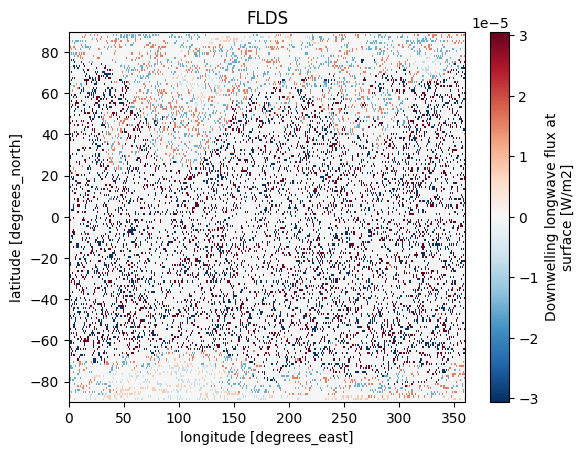

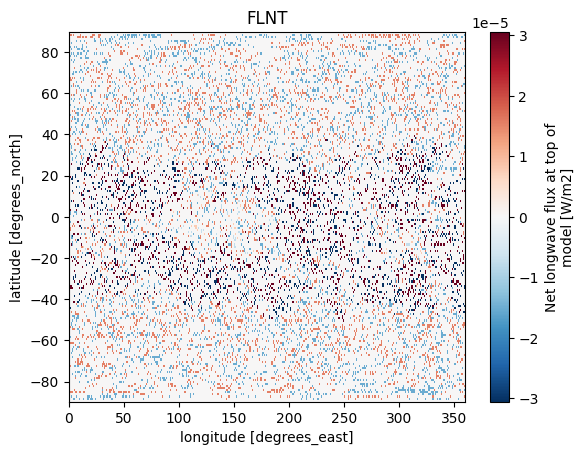

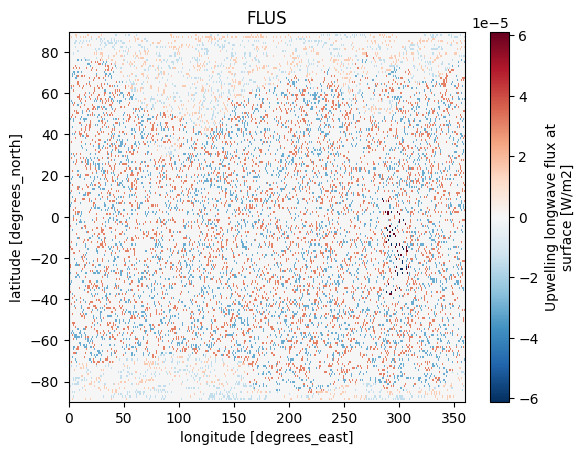

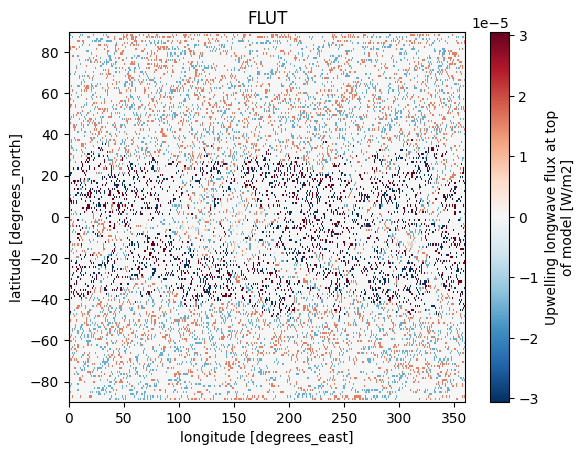

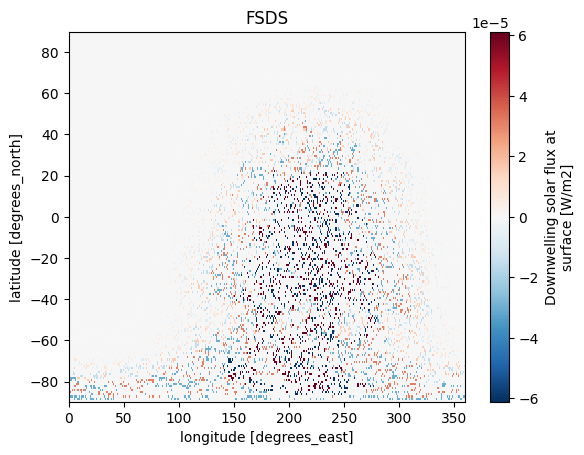

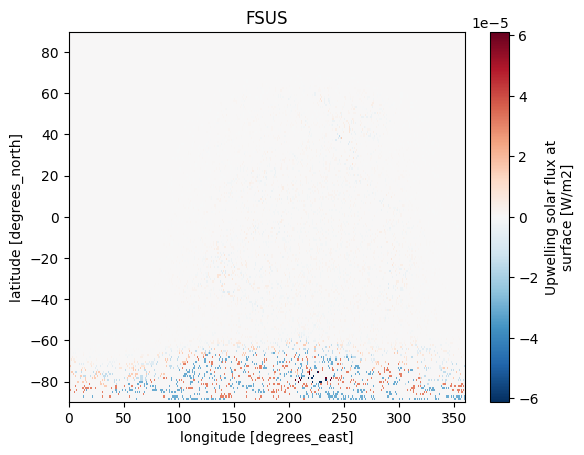

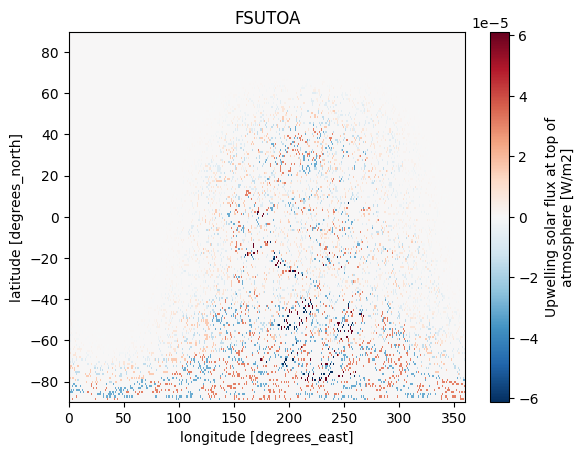

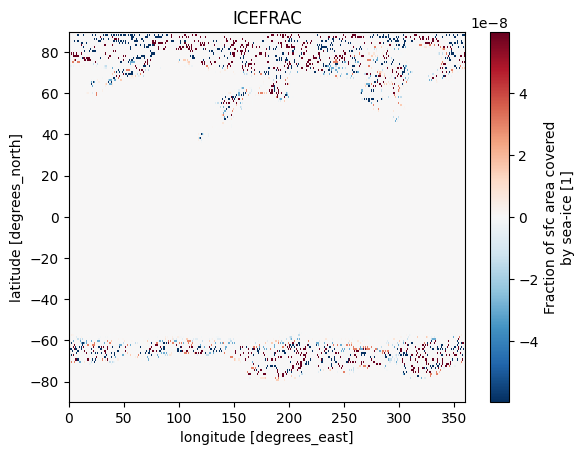

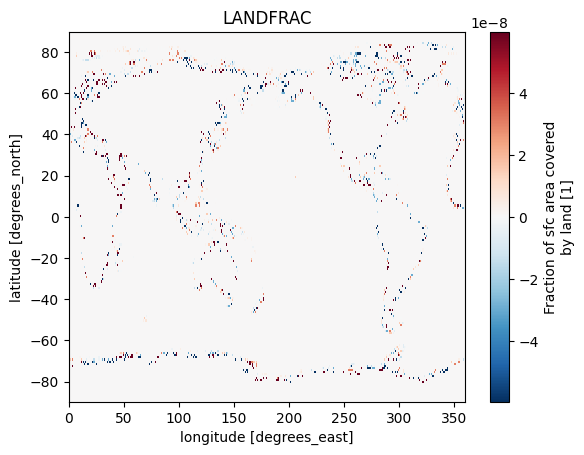

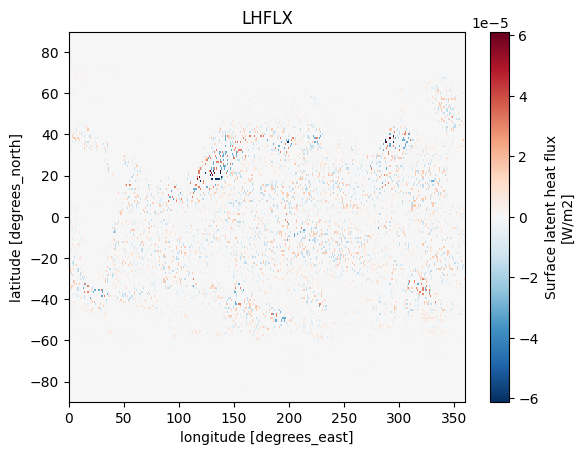

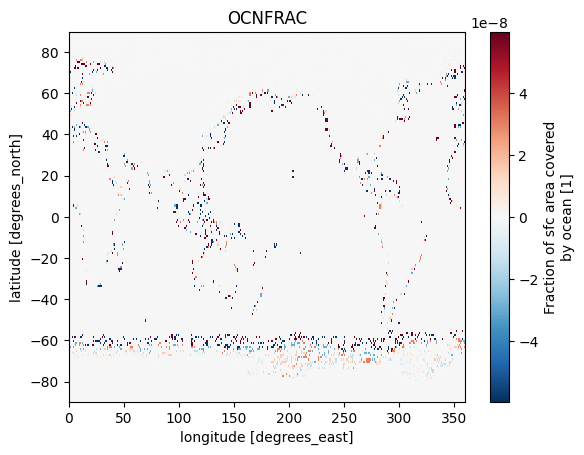

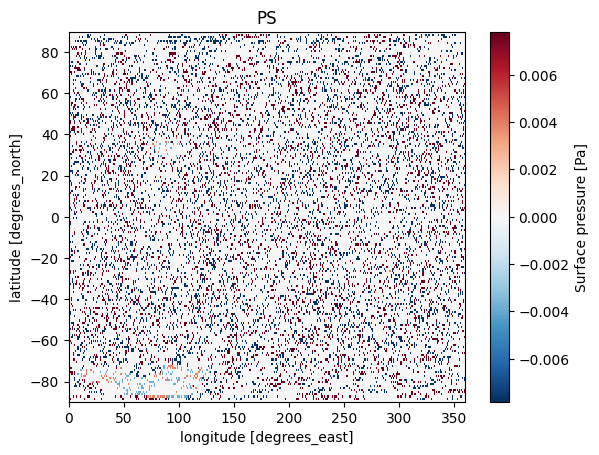

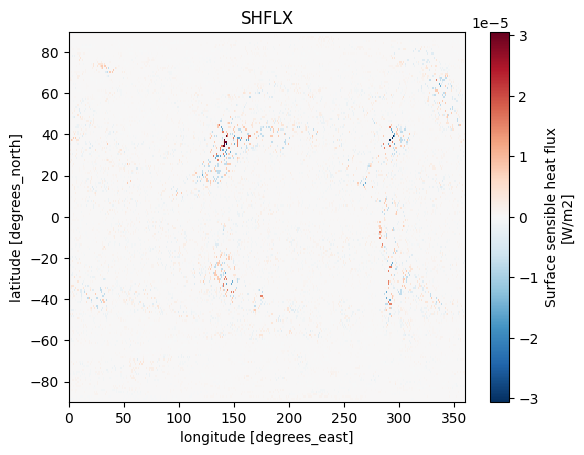

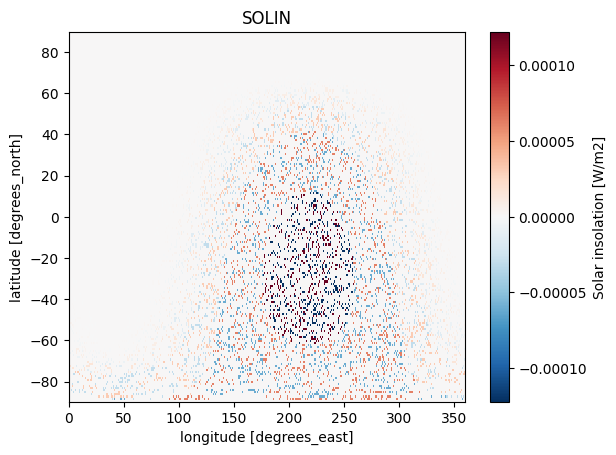

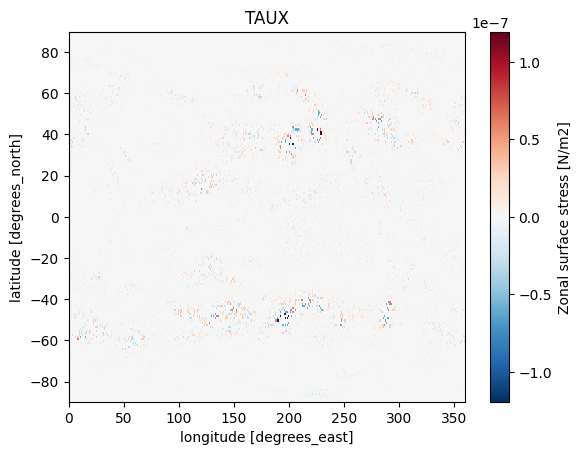

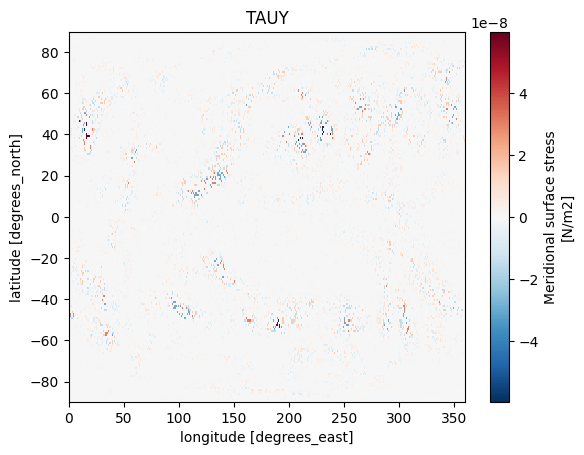

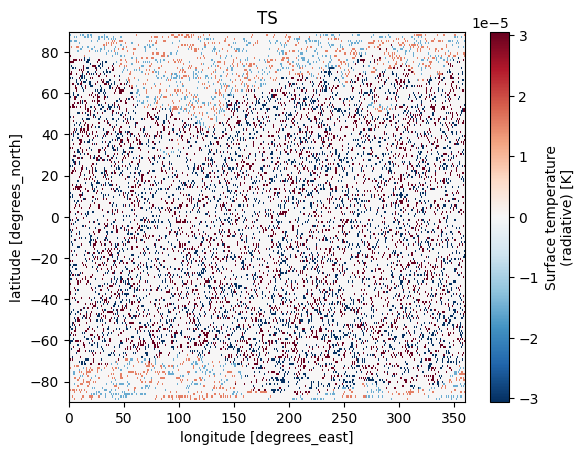

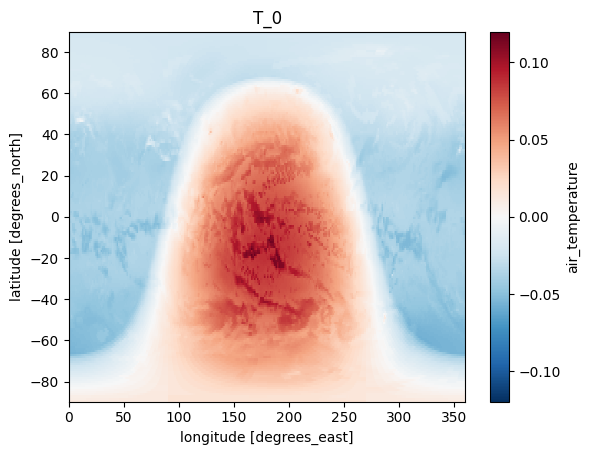

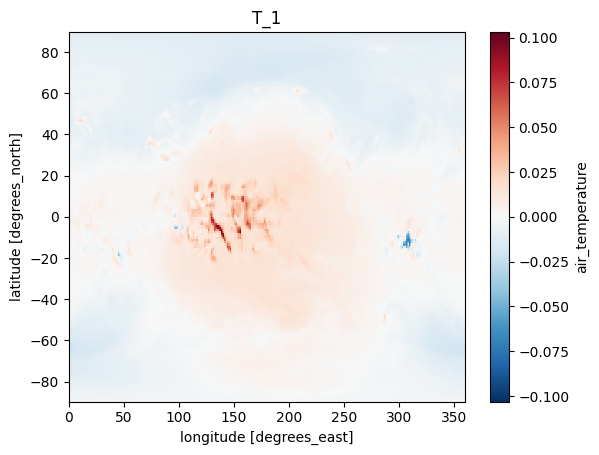

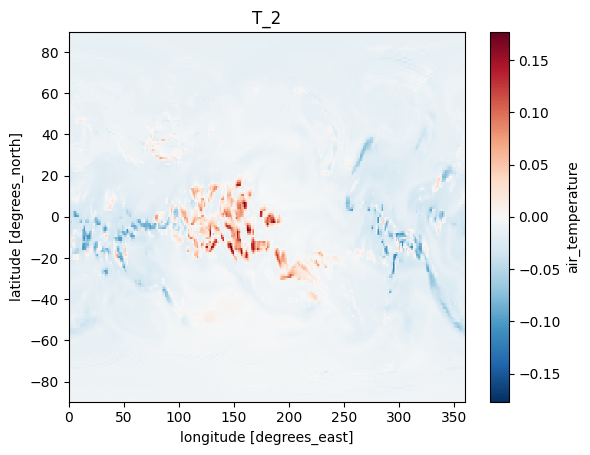

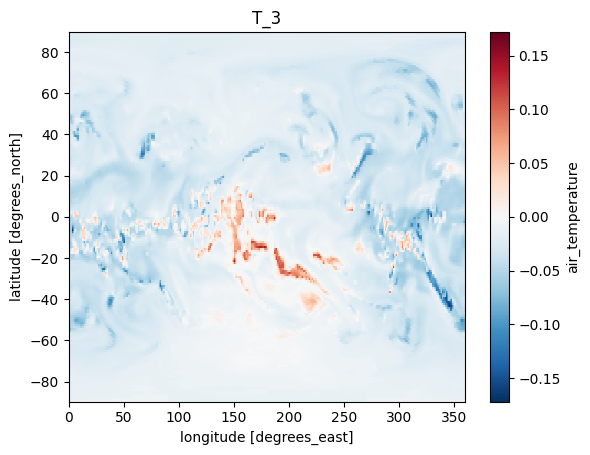

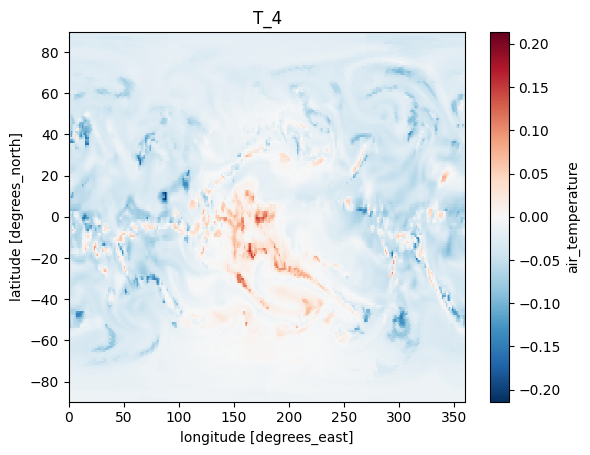

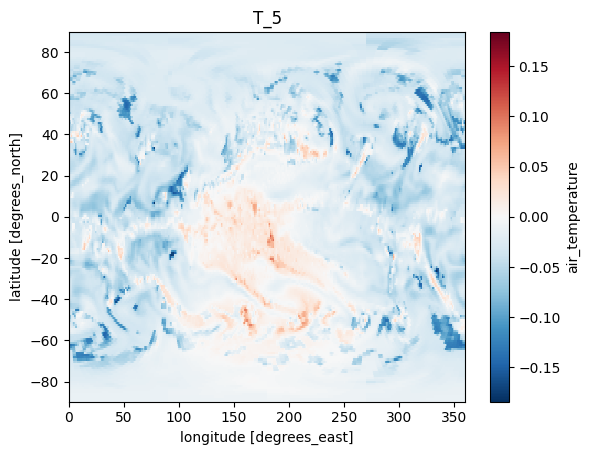

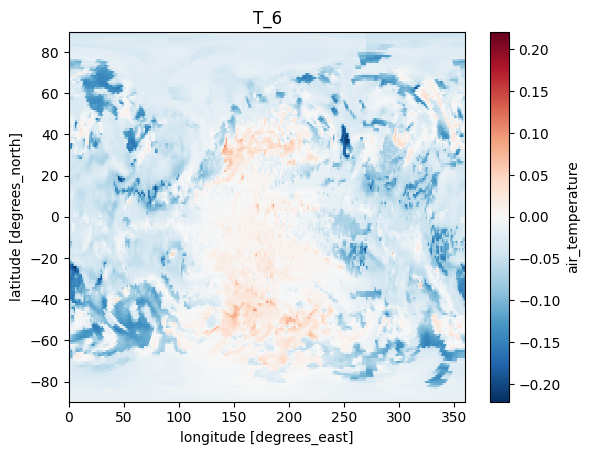

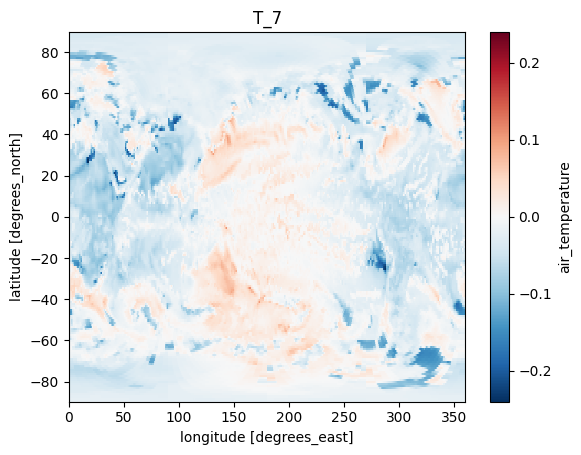

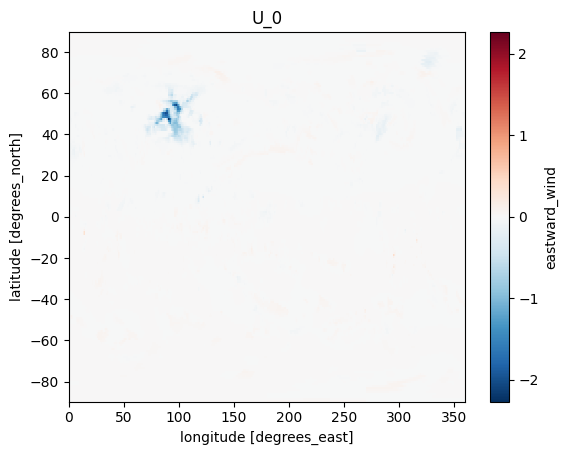

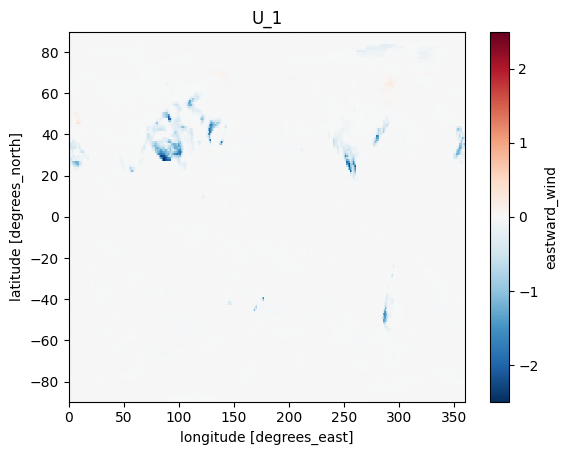

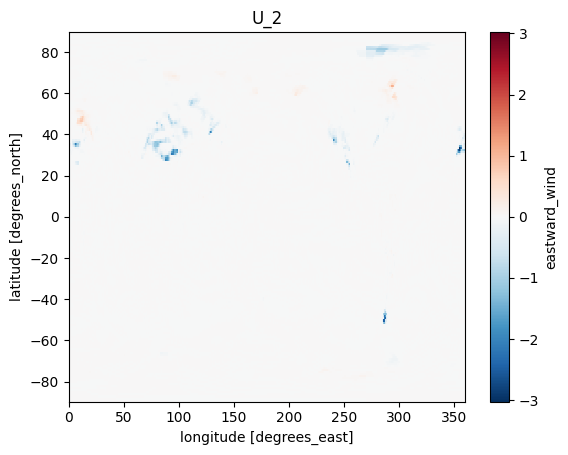

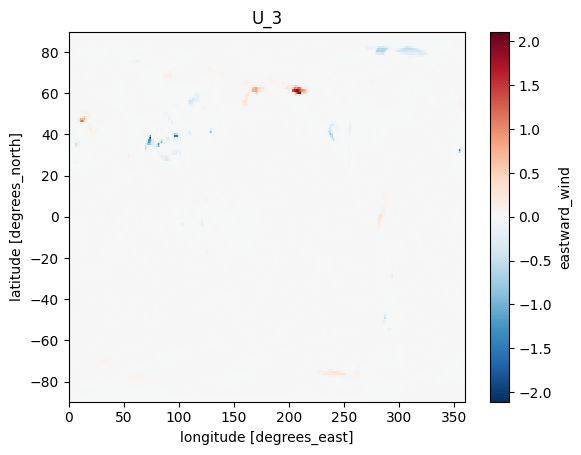

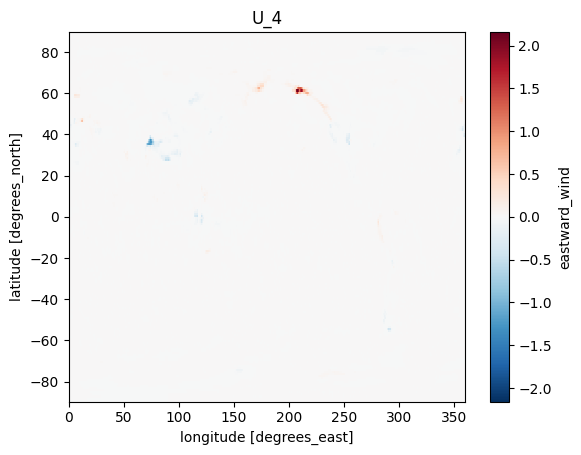

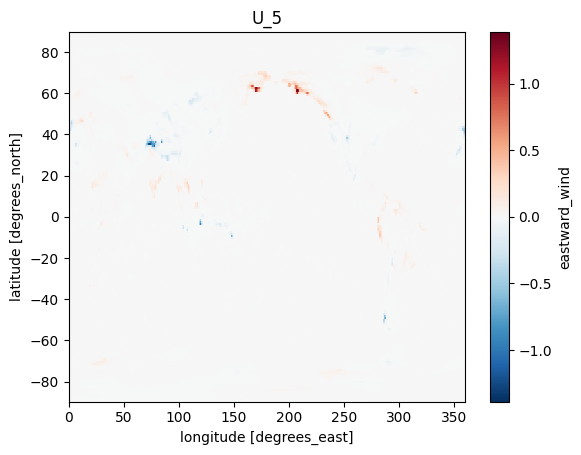

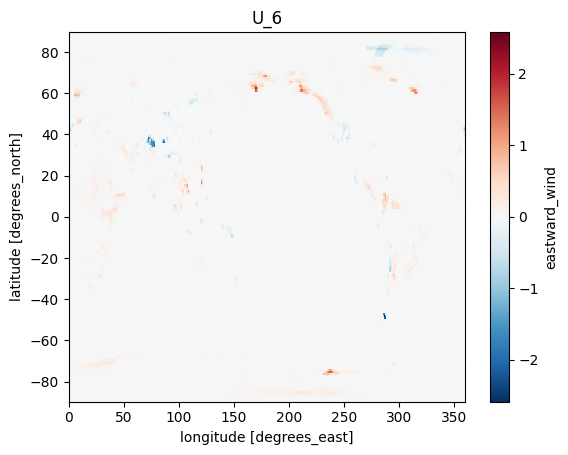

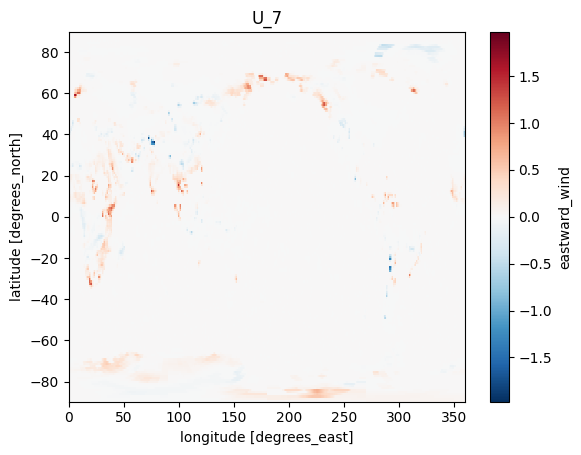

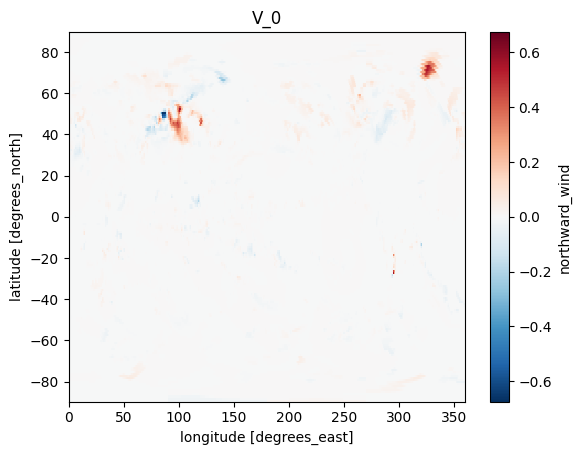

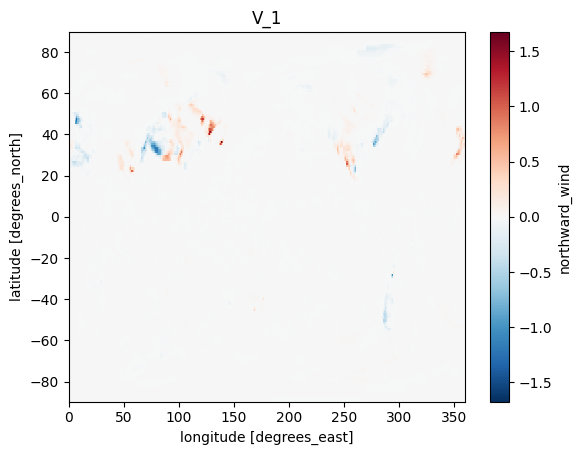

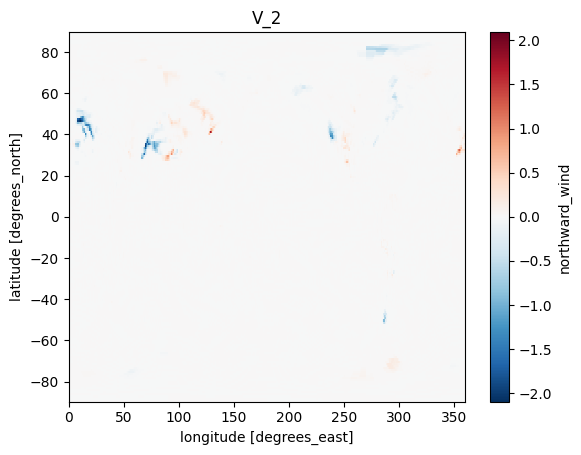

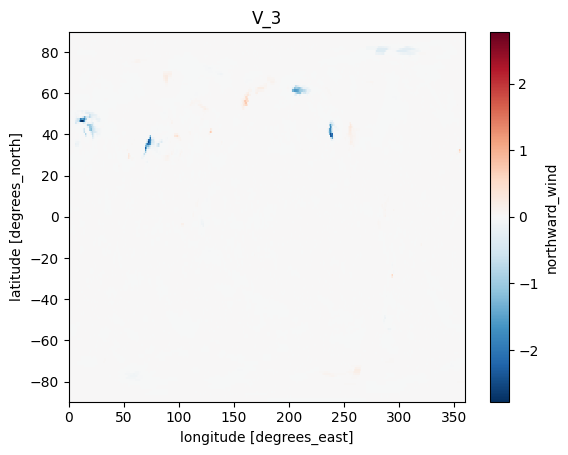

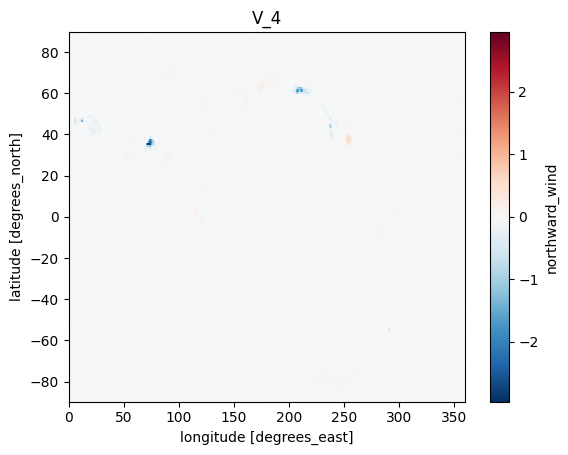

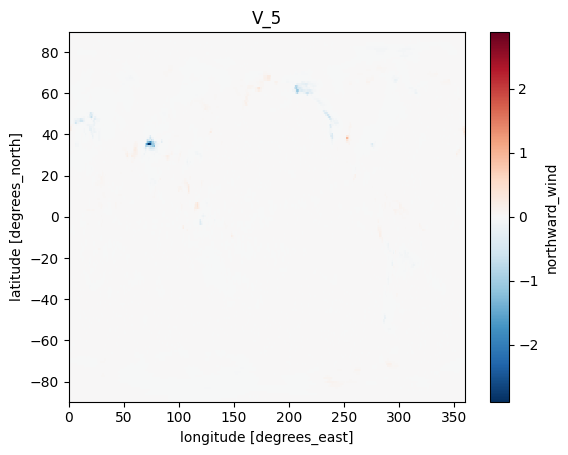

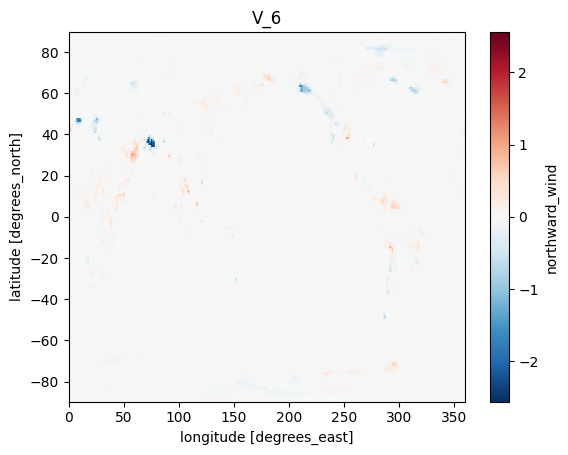

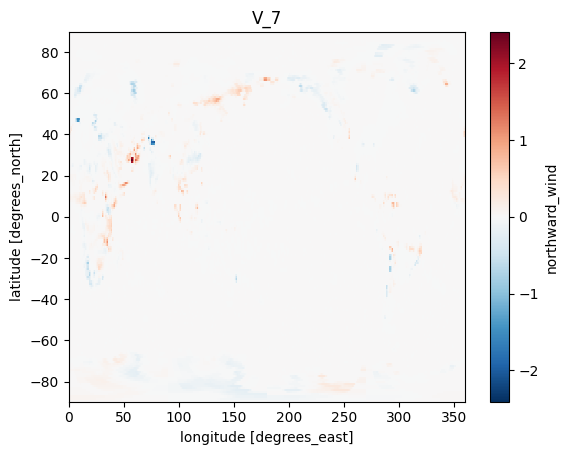

In [19]:
for var in diff.keys():
    if diff[var].dims == ("time", "lat", "lon"):
        plt.figure()
        diff[var].isel(time=-1).plot()
        plt.title(var)